# IMPORT LIBRARY

In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)

Using device: cpu


# LOAD DATA

In [30]:
df = pd.read_csv('ICICIBANK.csv')

In [31]:
df.shape

(5306, 15)

In [32]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,ICICIBANK,EQ,69.20,74.35,74.75,71.40,74.75,74.75,73.20,286260,2.095439e+12,NaN,NaN,NaN
1,2000-01-04,ICICIBANK,EQ,74.75,73.05,78.50,71.00,73.25,73.05,73.38,296264,2.173893e+12,NaN,NaN,NaN
2,2000-01-05,ICICIBANK,EQ,73.05,70.00,73.50,67.50,70.00,69.50,70.85,227624,1.612794e+12,NaN,NaN,NaN
3,2000-01-06,ICICIBANK,EQ,69.50,71.00,74.00,69.55,69.75,70.05,72.04,275149,1.982121e+12,NaN,NaN,NaN
4,2000-01-07,ICICIBANK,EQ,70.05,69.00,72.50,66.00,67.00,67.40,68.72,138809,9.538882e+11,NaN,NaN,NaN


In [33]:
#df.describe

In [34]:
df.info

<bound method DataFrame.info of             Date     Symbol Series  Prev Close    Open    High     Low  \
0     2000-01-03  ICICIBANK     EQ       69.20   74.35   74.75   71.40   
1     2000-01-04  ICICIBANK     EQ       74.75   73.05   78.50   71.00   
2     2000-01-05  ICICIBANK     EQ       73.05   70.00   73.50   67.50   
3     2000-01-06  ICICIBANK     EQ       69.50   71.00   74.00   69.55   
4     2000-01-07  ICICIBANK     EQ       70.05   69.00   72.50   66.00   
...          ...        ...    ...         ...     ...     ...     ...   
5301  2021-04-26  ICICIBANK     EQ      569.95  602.00  605.50  588.00   
5302  2021-04-27  ICICIBANK     EQ      591.10  593.25  601.95  591.10   
5303  2021-04-28  ICICIBANK     EQ      598.75  598.00  622.80  598.00   
5304  2021-04-29  ICICIBANK     EQ      621.35  622.55  628.45  609.00   
5305  2021-04-30  ICICIBANK     EQ      621.45  610.10  616.35  598.10   

        Last   Close    VWAP    Volume      Turnover    Trades  \
0      74.75 

In [35]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
features =["Prev Close","Open","High","Low","Last","Close","VWAP",
           "Volume","Turnover","Trades","Deliverable Volume"]
data_df = df[features].copy()

# DATA CLEANING

In [36]:
data_df = data_df.replace([np.inf, -np.inf], np.nan)
data_df = data_df.interpolate(method="linear",limit_direction = "both")
data_df = data_df.fillna(method="ffill").fillna(method="bfill")

In [37]:
print(df.isnull().sum())

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     517
%Deliverble            517
dtype: int64


# LOG TRANSFORM

In [38]:
log_features = ["Volume", "Turnover", "Trades","Deliverable Volume"]
for col in log_features:
    data_df[col] = np.log1p(data_df[col])

# NORMALIZATION

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(data_df.values)
num_features = data.shape[1]

# CREATING SEQUENCE

In [40]:
def create_sequences(data,input_steps =20, output_steps=5):
    X, y = [], []
    for i in range(len(data)- input_steps - output_steps):
        X.append(data[i:i+input_steps])
        y.append(data[i+input_steps:i+input_steps+output_steps])
    return np.array(X), np.array(y)

Input_steps = 20
Output_steps = 5
X, y = create_sequences(data,Input_steps,Output_steps)

In [41]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5281, 20, 11)
y shape: (5281, 5, 11)


In [42]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [43]:
class TimeSeriesDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32, shuffle=False)

# MODEL

In [44]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_steps, num_features):
        super().__init__()
        self.rnn = nn.LSTM(input_size,hidden_size,batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_steps * num_features)
        self.output_steps = output_steps
        self.num_features = num_features
        
    def forward(self, x):
        out,_ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.view(-1, self.output_steps, self.num_features)
model = RNNModel(num_features, 64, Output_steps, num_features).to(device)

/Users/martha13/anaconda3/lib/python3.11/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


# WEIGHTED LOSS

In [45]:
weights = np.array([1,1,1,1,1,1,1, 0.2,0.2,0.3,0.2], dtype=np.float32)
weights = torch.tensor(weights).to(device)
def weighted_mse(pred, target):
    return ((pred - target) ** 2 * weights).mean()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# EARLY STOPPING

In [46]:
best_loss = float("inf")
patience = 5
counter = 0

# TRAINING

In [47]:
epochs = 50 
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = weighted_mse(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break
model.load_state_dict(torch.load("best_model.pth"))

Epoch 1, Loss: 0.1677
Epoch 2, Loss: 0.0302
Epoch 3, Loss: 0.0269
Epoch 4, Loss: 0.0257
Epoch 5, Loss: 0.0245
Epoch 6, Loss: 0.0242
Epoch 7, Loss: 0.0239
Epoch 8, Loss: 0.0236
Epoch 9, Loss: 0.0234
Epoch 10, Loss: 0.0231
Epoch 11, Loss: 0.0230
Epoch 12, Loss: 0.0229
Epoch 13, Loss: 0.0228
Epoch 14, Loss: 0.0227
Epoch 15, Loss: 0.0226
Epoch 16, Loss: 0.0225
Epoch 17, Loss: 0.0223
Epoch 18, Loss: 0.0224
Epoch 19, Loss: 0.0224
Epoch 20, Loss: 0.0222
Epoch 21, Loss: 0.0222
Epoch 22, Loss: 0.0223
Epoch 23, Loss: 0.0224
Epoch 24, Loss: 0.0221
Epoch 25, Loss: 0.0221
Epoch 26, Loss: 0.0221
Epoch 27, Loss: 0.0223
Epoch 28, Loss: 0.0220
Epoch 29, Loss: 0.0220
Epoch 30, Loss: 0.0220
Epoch 31, Loss: 0.0221
Epoch 32, Loss: 0.0220
Epoch 33, Loss: 0.0219
Epoch 34, Loss: 0.0218
Epoch 35, Loss: 0.0218
Epoch 36, Loss: 0.0217
Epoch 37, Loss: 0.0216
Epoch 38, Loss: 0.0218
Epoch 39, Loss: 0.0218
Epoch 40, Loss: 0.0217
Epoch 41, Loss: 0.0217
Epoch 42, Loss: 0.0217
Early stopping


<All keys matched successfully>

# PREDICTION

In [48]:
model.eval()
preds=[]
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch).cpu().numpy()
        preds.append(output)
        actuals.append(y_batch.numpy())
preds = np.concatenate(preds, axis = 0)
actuals = np.concatenate(actuals, axis = 0)

# INVERSE TRANSFORM

In [49]:
preds_reshaped = preds.reshape(-1, num_features)
actuals_reshaped = actuals.reshape(-1, num_features)
preds_log = scaler.inverse_transform(preds_reshaped.copy())
actuals_log = scaler.inverse_transform(actuals_reshaped.copy())
preds_inv = preds_log.copy()
actuals_inv = actuals_log.copy()

for col in log_features:
    ind = features.index(col)
    preds_inv[:, ind] = np.expm1(preds_inv[:, ind])
    actuals_inv[:, ind] = np.expm1(actuals_inv[:, ind])

# EVALUATION AND PLOTTING

Prev Close >> MSE:441.26, RMSE:21.01, MAE:15.21, R2:0.9501
Open >> MSE:433.21, RMSE:20.81, MAE:14.41, R2:0.9511
High >> MSE:434.53, RMSE:20.85, MAE:15.29, R2:0.9520
Low >> MSE:359.60, RMSE:18.96, MAE:12.91, R2:0.9584
Last >> MSE:463.07, RMSE:21.52, MAE:15.49, R2:0.9479
Close >> MSE:425.02, RMSE:20.62, MAE:14.63, R2:0.9522
VWAP >> MSE:573.14, RMSE:23.94, MAE:16.98, R2:0.9352
Volume >> MSE:0.43, RMSE:0.65, MAE:0.52, R2:-0.2735
Turnover >> MSE:0.44, RMSE:0.66, MAE:0.52, R2:-0.0184
Trades >> MSE:0.27, RMSE:0.52, MAE:0.40, R2:0.1926
Deliverable Volume >> MSE:0.42, RMSE:0.65, MAE:0.50, R2:-0.3715


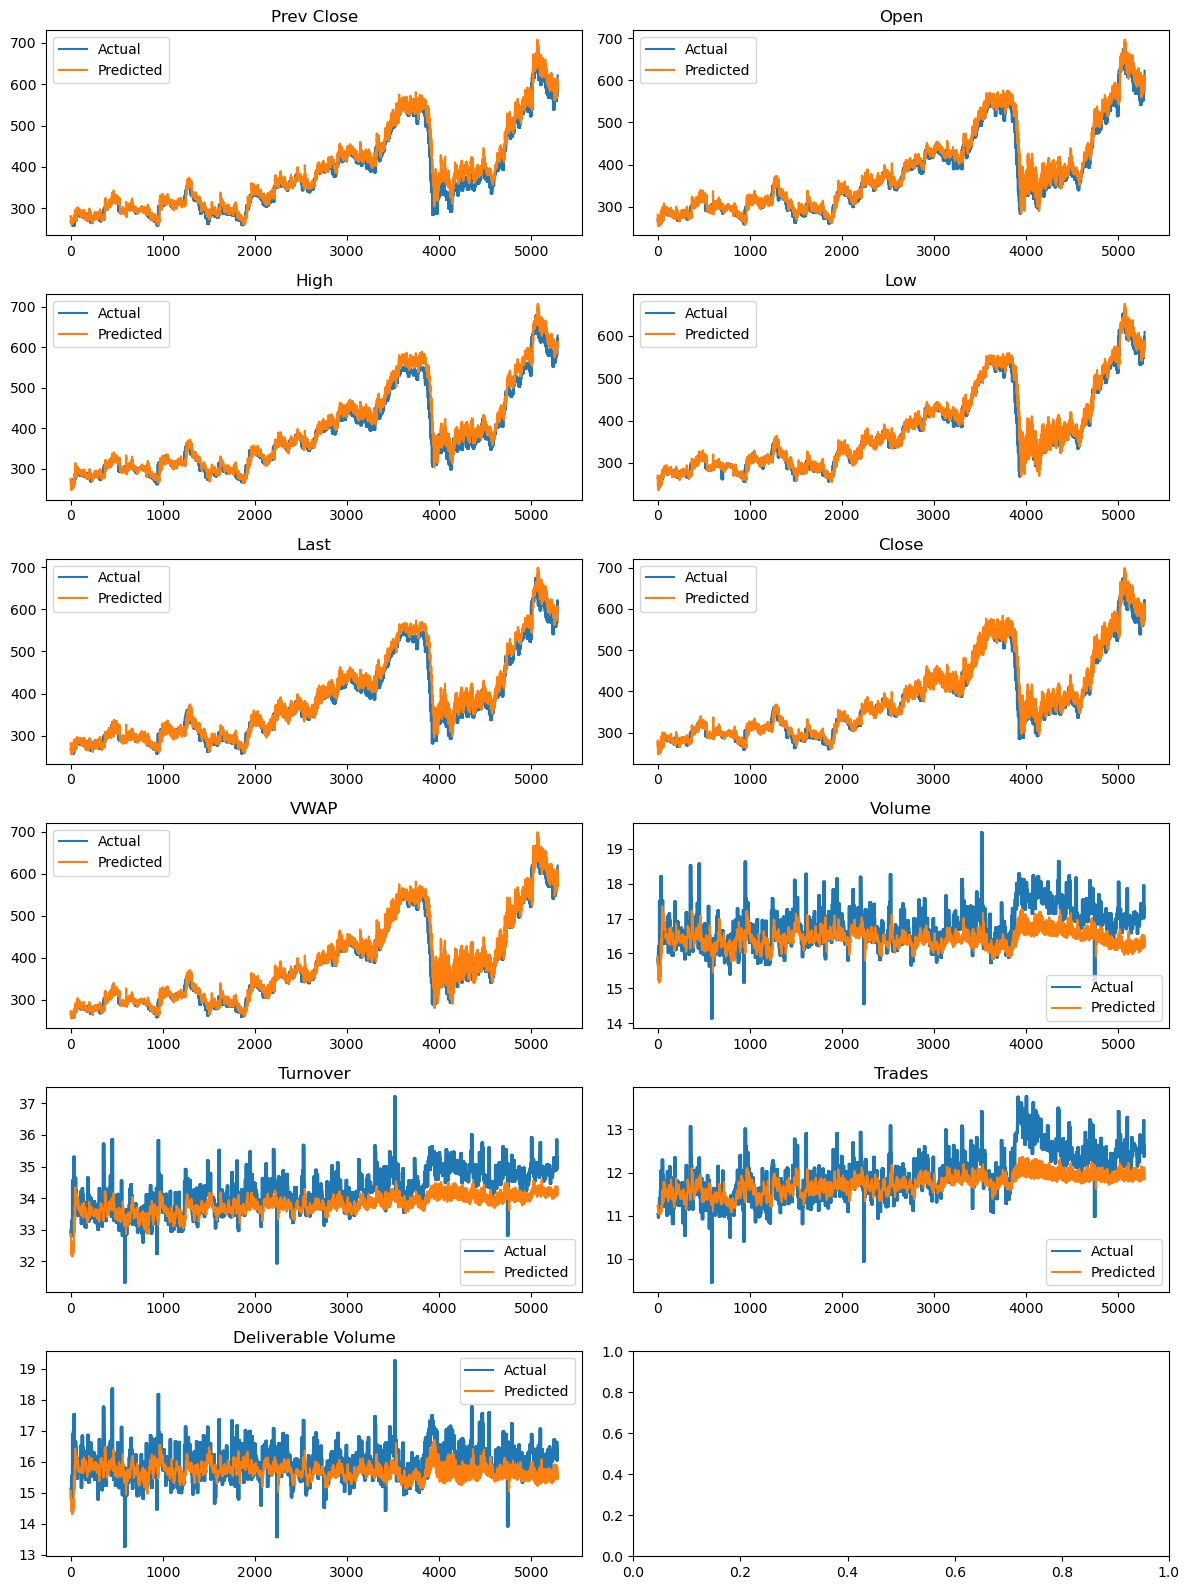

In [50]:
fig, axes = plt.subplots(6, 2, figsize=(12, 16))
axes = axes.flatten()
mse_list = []
rmse_list = []
mae_list = []
r2_list = []

for i, feature in enumerate(features):
    if feature in log_features:
        actual_f = actuals_log[:, i]
        pred_f = preds_log[:, i]
    else:
        actual_f = actuals_inv[:, i]
        pred_f = preds_inv[:, i]

    mse = mean_squared_error(actual_f, pred_f)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual_f, pred_f)
    r2 = r2_score(actual_f, pred_f)

    mse_list.append(mse)
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

    print(f"{feature} >> MSE:{mse:.2f}, RMSE:{rmse:.2f}, MAE:{mae:.2f}, R2:{r2:.4f}")

    axes[i].plot(actual_f, label="Actual")
    axes[i].plot(pred_f, label="Predicted")
    axes[i].set_title(feature)
    axes[i].legend()

plt.tight_layout()
plt.show()

# OVERALL PREDICTION

In [51]:
print("\nFINAL OVERALL :-")
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))
print("MAE :", np.mean(mae_list))
print("R2  :", np.mean(r2_list))


FINAL OVERALL :-
MSE : 284.6708
RMSE: 13.652973
MAE : 9.71412
R2  : 0.5614624547170914


# CLOSE FEATURES

In [52]:
close_ind = features.index("Close")
close_actual = actuals_inv[:, close_ind]
close_pred = preds_inv[:, close_ind]

print("\nCLOSE FEATURE:-")
print("MSE :", mean_squared_error(close_actual, close_pred))
print("RMSE:", np.sqrt(mean_squared_error(close_actual, close_pred)))
print("MAE :", mean_absolute_error(close_actual, close_pred))
print("R2  :", r2_score(close_actual, close_pred))


CLOSE FEATURE:-
MSE : 425.02432
RMSE: 20.616117
MAE : 14.62829
R2  : 0.952153625668849


# CLOSE PRICE PREDICTION PLOT

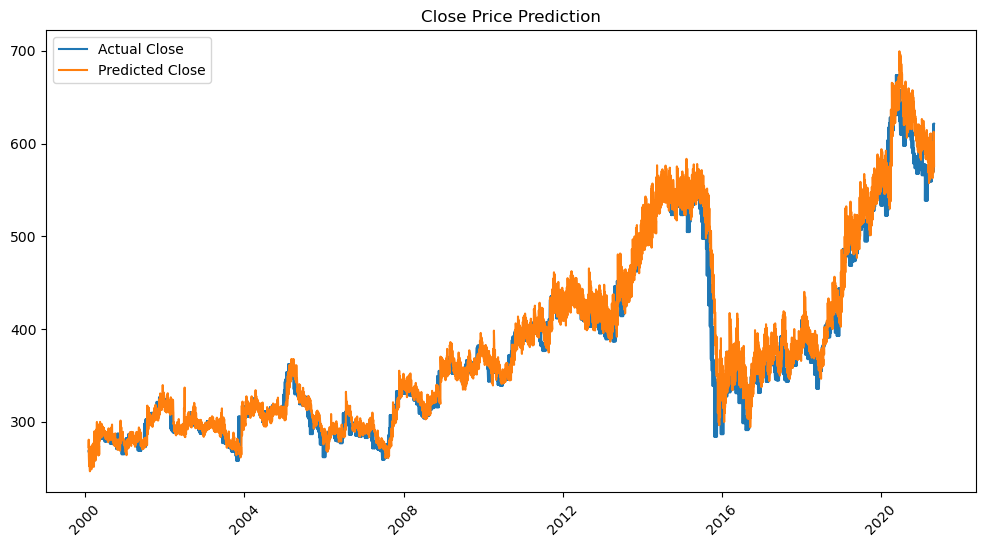

In [53]:
dates = df["Date"].values[-len(close_actual):]
plt.figure(figsize=(12,6))
plt.plot(dates, close_actual, label="Actual Close")
plt.plot(dates, close_pred, label="Predicted Close")
plt.title("Close Price Prediction")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# 5 DAYS FUTURE PREDICTION

In [27]:
last_sequence = data[-Input_steps:]
last_sequence = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)
future_pred = model(last_sequence).cpu().detach().numpy()
future_pred = future_pred.reshape(-1, num_features)
future_log = scaler.inverse_transform(future_pred.copy())
future_inv = future_log.copy()

for col in log_features:
    ind = features.index(col)
    future_inv[:, ind] = np.expm1(future_inv[:, ind])

print("\nNEXT 5 DAYS PREDICTION:-")
future_df = pd.DataFrame(future_inv, columns=features)
print(future_df)


NEXT 5 DAYS PREDICTION:-
   Prev Close        Open        High         Low        Last       Close  \
0  598.668945  610.210266  605.426941  596.638062  607.244751  598.159729   
1  593.614258  612.111755  605.239502  575.788086  600.345703  610.502625   
2  607.446777  613.235107  624.851257  594.876953  613.437439  614.369263   
3  576.736389  614.457886  636.293884  608.450439  596.747437  601.190613   
4  604.884094  616.147034  621.626892  583.807068  604.933533  597.588623   

         VWAP      Volume      Turnover         Trades  Deliverable Volume  
0  598.144043  10056153.0  6.641670e+14  176925.968750           5246230.5  
1  601.700073   9937991.0  5.913672e+14  158422.218750           5515243.0  
2  616.285889   9554921.0  5.620115e+14  149112.375000           4737599.5  
3  584.116821   8687360.0  5.574890e+14  146992.796875           4638262.5  
4  606.273071   8528859.0  4.698793e+14  140543.046875           4592198.0  
